<a href="https://colab.research.google.com/github/Belcamino/Ex2.ReteNeurale/blob/master/ReteNeurale.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Esempio Didattico di Addestramento di una Rete Neurale in Python

Questo esempio ti guiderà attraverso la creazione e l'addestramento di una semplice rete neurale per un problema di regressione. Useremo TensorFlow/Keras per definire e addestrare il modello.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.19.0


#### 1. Generazione di un Dataset Sintetico

Creeremo un dataset semplice con una relazione lineare tra input (X) e output (y), aggiungendo un po' di rumore per simulare dati reali.

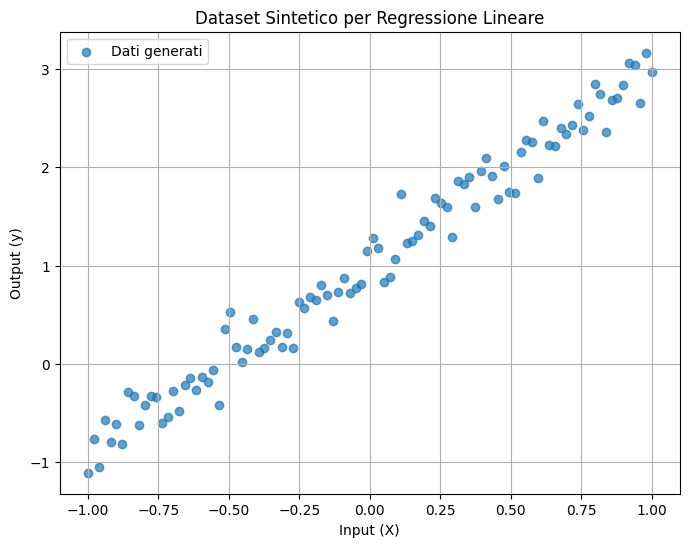

In [ ]:
# Genera dati di input (X)
X = np.linspace(-1, 1, 100).reshape(-1, 1) # 100 punti tra -1 e 1

# Genera dati di output (y) con una relazione lineare e rumore
y = 2 * X + 1 + np.random.normal(0, 0.2, X.shape) # y = 2x + 1 + rumore

# Visualizza il dataset
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Dati generati', alpha=0.7)
plt.xlabel('Input (X)')
plt.ylabel('Output (y)')
plt.title('Dataset Sintetico per Regressione Lineare')
plt.grid(True)
plt.legend()
plt.show()

#### 2. Definizione del Modello di Rete Neurale

Definiremo una rete neurale sequenziale molto semplice con un solo strato nascosto (Dense Layer) e uno strato di output. Dato che è un problema di regressione, lo strato di output non avrà una funzione di attivazione (o userà una lineare predefinita).

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(1,)), # Lo strato di input si aspetta 1 caratteristica
    layers.Dense(units=10, activation='tanh', name='hidden_layer_1'), # Strato nascosto con 10 neuroni e attivazione Tanh
    layers.Dense(units=1, name='output_layer') # Strato di output con 1 neurone per la regressione
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

#### 3. Compilazione del Modello

Prima di addestrare il modello, dobbiamo compilarlo. Questo include la specificazione di:
- **Ottimizzatore**: L'algoritmo usato per aggiornare i pesi della rete (es. `adam`).
- **Funzione di Loss (Perdita)**: Una misura di quanto bene il modello sta performando (es. `mean_squared_error` per la regressione).
- **Metrica**: Una metrica per monitorare le prestazioni durante l'addestramento (es. `mean_absolute_error`).

In [ ]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mean_absolute_error']
)

#### 4. Addestramento del Modello

Ora addestriamo il modello utilizzando il metodo `fit()`. Forniamo i dati di input (X), i dati di output target (y), il numero di epoche (quante volte il modello vedrà l'intero dataset) e la dimensione del batch.

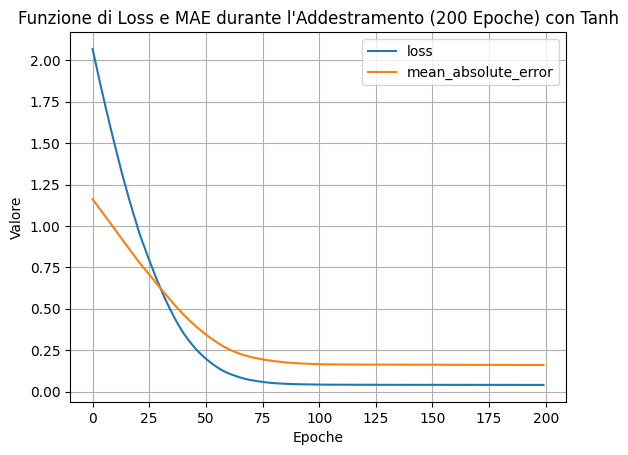

In [ ]:
import pandas as pd

history = model.fit(
    X, y,
    epochs=200, # Aumento il numero di epoche di addestramento
    batch_size=32, # Dimensione del batch
    verbose=0 # Non mostrare l'output per ogni epoca, solo il finale
)

# Converti la cronologia in un DataFrame per una visualizzazione più semplice
history_df = pd.DataFrame(history.history)

# Visualizza la funzione di loss nel tempo
history_df.loc[:, ['loss', 'mean_absolute_error']].plot()
plt.xlabel('Epoche')
plt.ylabel('Valore')
plt.title('Funzione di Loss e MAE durante l\'Addestramento (200 Epoche) con Tanh')
plt.grid(True)
plt.show()

#### 5. Valutazione del Modello e Predizioni

Dopo l'addestramento, possiamo usare il modello per fare predizioni su nuovi dati e valutarne le prestazioni.

1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


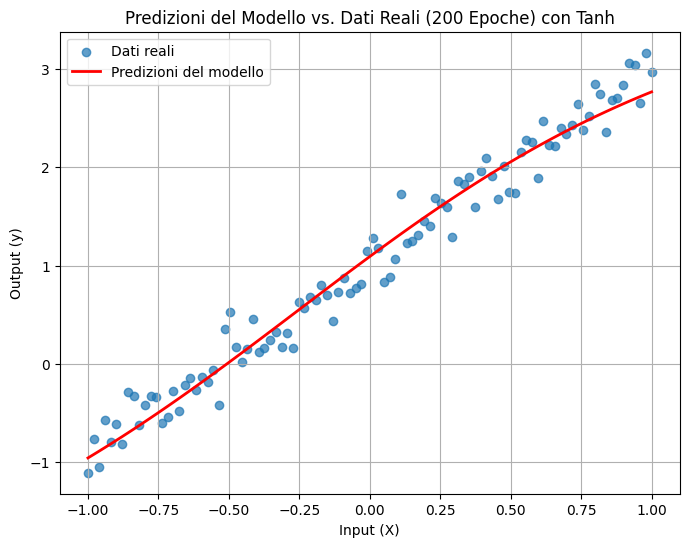

Loss finale (MSE): 0.0402
Errore Medio Assoluto (MAE) finale: 0.1604


In [ ]:
# Fai predizioni sui dati di input originali
y_pred = model.predict(X)

# Visualizza i risultati
plt.figure(figsize=(8, 6))
plt.scatter(X, y, label='Dati reali', alpha=0.7)
plt.plot(X, y_pred, color='red', label='Predizioni del modello', linewidth=2)
plt.xlabel('Input (X)')
plt.ylabel('Output (y)')
plt.title('Predizioni del Modello vs. Dati Reali (200 Epoche) con Tanh')
plt.grid(True)
plt.legend()
plt.show()

# Valuta il modello sui dati di addestramento
loss, mae = model.evaluate(X, y, verbose=0)
print(f"Loss finale (MSE): {loss:.4f}")
print(f"Errore Medio Assoluto (MAE) finale: {mae:.4f}")

### Conclusione

Questo esempio dimostra i passi fondamentali per addestrare una rete neurale:
1. **Preparazione dei dati**: Generare o caricare i dati e pre-processarli.
2. **Definizione del modello**: Costruire l'architettura della rete neurale.
3. **Compilazione del modello**: Configurare l'ottimizzatore, la funzione di loss e le metriche.
4. **Addestramento del modello**: Utilizzare il metodo `fit()` per addestrare la rete sui dati.
5. **Valutazione e predizione**: Usare il modello addestrato per fare previsioni e valutarne le prestazioni.

Questo è un esempio molto semplice, ma i principi si applicano anche a modelli più complessi e a dataset più grandi!